# Week 3 Assignment - HELP International Country Clustering

Dataset: Country-data.csv

HELP International has raised around  million and needs to decide which countries should receive aid first. The aim of this analysis is to group countries using socio-economic and health indicators, then identify the countries with the highest need.

Workflow:
- Load and inspect the dataset
- Check data quality
- Explore important patterns in the indicators
- Scale the numerical features
- Use PCA for visualization
- Apply K-Means, DBSCAN, and Hierarchical clustering
- Profile the clusters and recommend priority countries


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Data Loading and Initial Inspection

In [2]:
data_path = 'Country-data.csv'
dictionary_path = 'data-dictionary.csv'

df = pd.read_csv(data_path)
data_dictionary = pd.read_csv(dictionary_path)

print('Dataset shape:', df.shape)
display(df.head())
display(data_dictionary)


Dataset shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


In [3]:
display(df.info())
display(df.describe().T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## 3. Data Quality Checks

In [4]:
quality_report = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique()
})

print('Duplicate rows:', df.duplicated().sum())
display(quality_report)


Duplicate rows: 0


,missing_values,missing_percent,unique_values
country,0,0.0,167
child_mort,0,0.0,139
exports,0,0.0,147
health,0,0.0,147
imports,0,0.0,151
income,0,0.0,156
inflation,0,0.0,156
life_expec,0,0.0,127
total_fer,0,0.0,138
gdpp,0,0.0,157


The dataset has one row per country and all modeling columns are numeric. Since there are no missing values or duplicate rows, no imputation or deduplication is required.

## 4. Exploratory Data Analysis

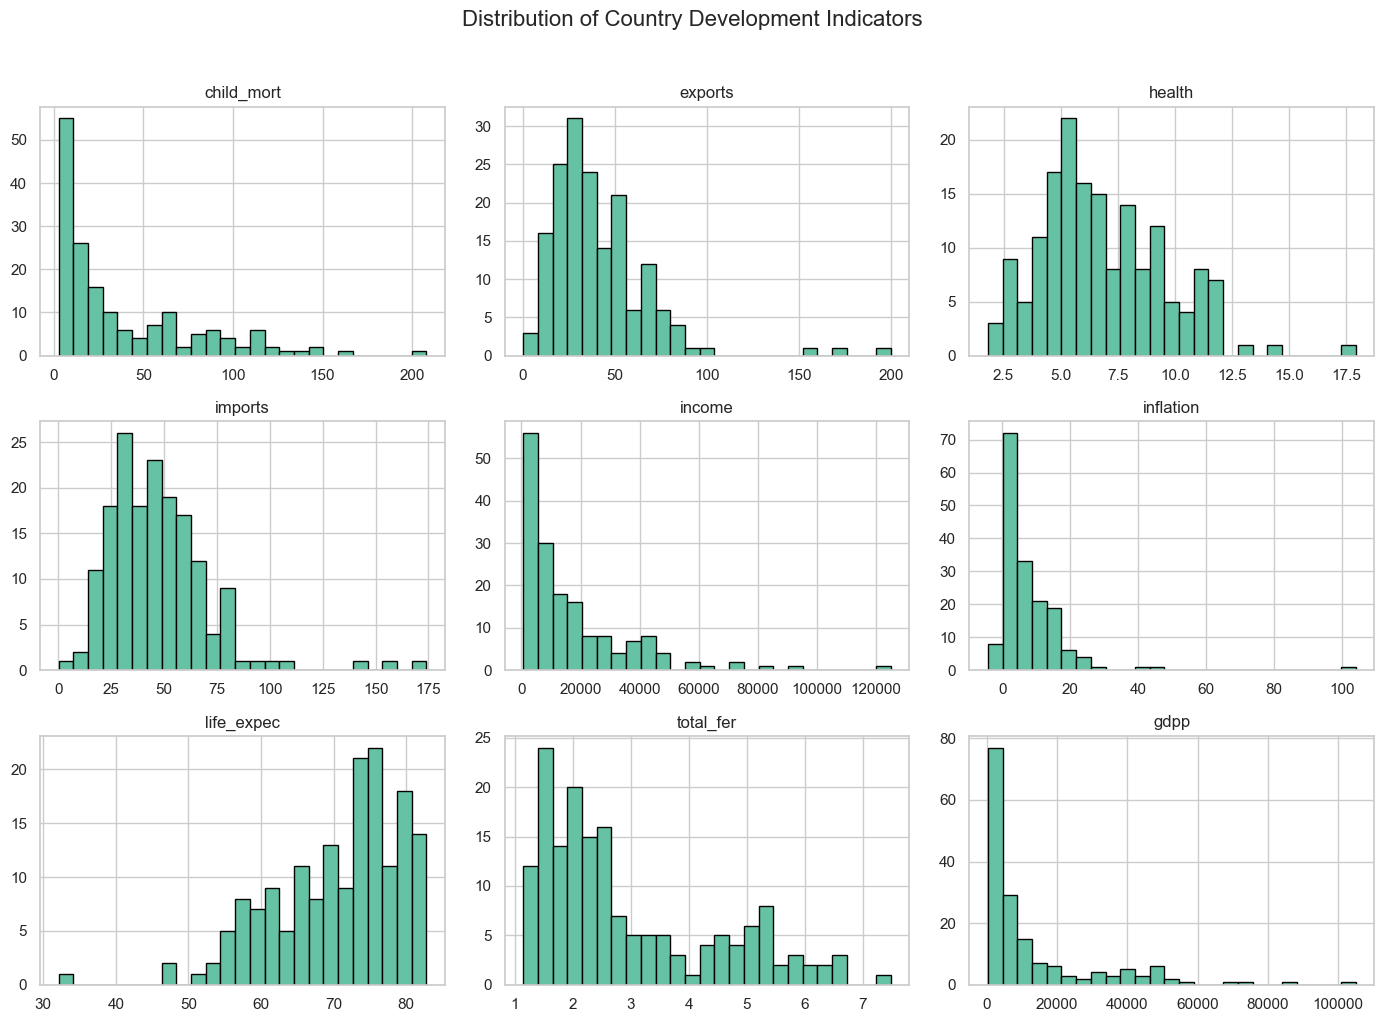

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

df[numeric_cols].hist(bins=25, figsize=(14, 10), edgecolor='black')
plt.suptitle('Distribution of Country Development Indicators', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


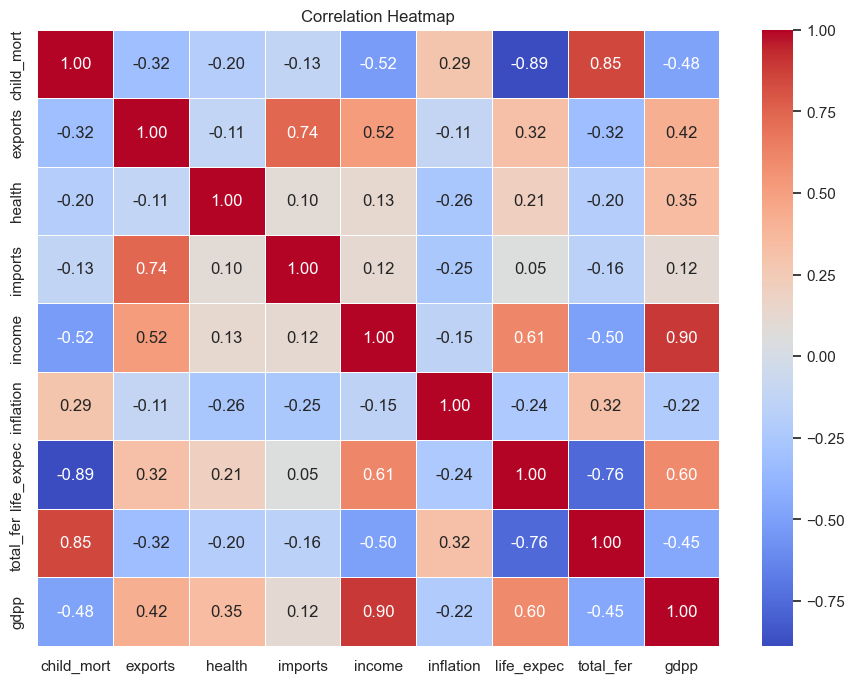

In [6]:
plt.figure(figsize=(11, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


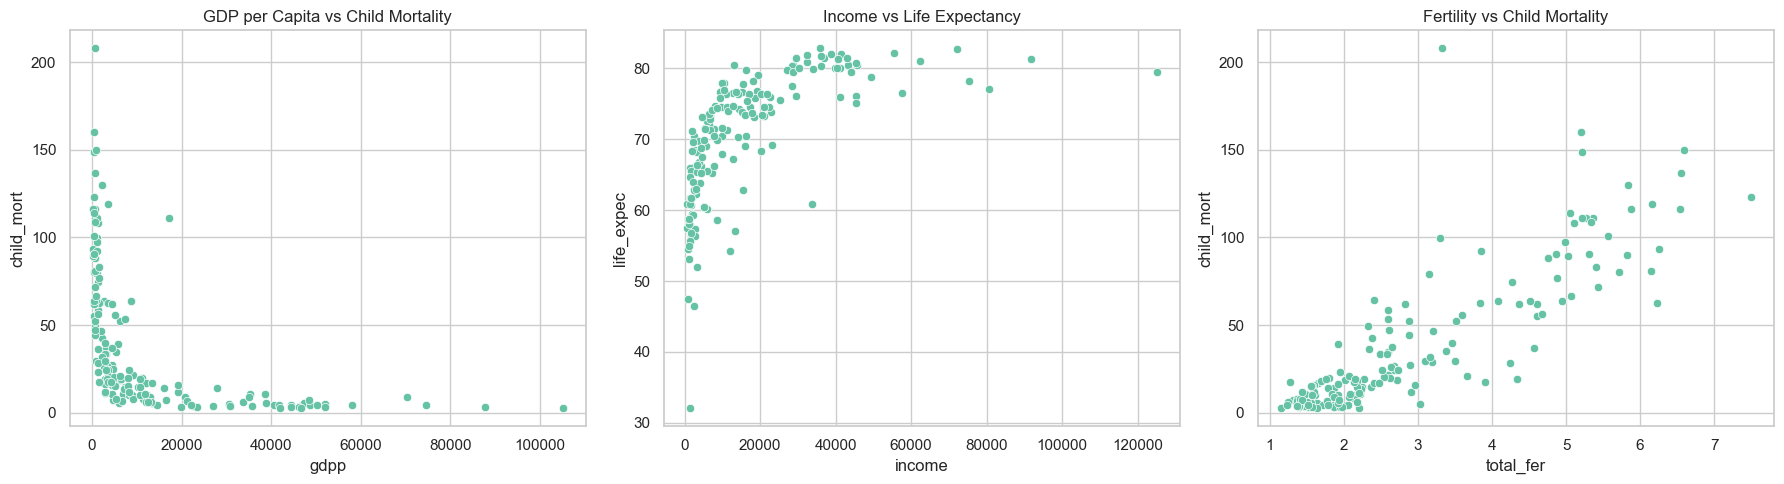

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='gdpp', y='child_mort', ax=axes[0])
axes[0].set_title('GDP per Capita vs Child Mortality')

sns.scatterplot(data=df, x='income', y='life_expec', ax=axes[1])
axes[1].set_title('Income vs Life Expectancy')

sns.scatterplot(data=df, x='total_fer', y='child_mort', ax=axes[2])
axes[2].set_title('Fertility vs Child Mortality')

plt.tight_layout()
plt.show()


Key EDA expectations:
- Countries with higher GDP and income usually have lower child mortality.
- Life expectancy tends to increase with income.
- Child mortality and fertility are positively related, which is common in less developed economies.


## 5. Feature Preparation

In [8]:
# Keep country names for interpretation and scale only numeric indicators.
X = df.drop(columns='country')
countries = df['country']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
display(scaled_df.head())


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## 6. PCA for Visualization and Dimensionality Reduction

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.459517,0.459517
1,PC2,0.171816,0.631334
2,PC3,0.130043,0.761376
3,PC4,0.110532,0.871908
4,PC5,0.073402,0.945310
5,PC6,0.024842,0.970152
6,PC7,0.012604,0.982757
7,PC8,0.009813,0.992569
8,PC9,0.007431,1.000000


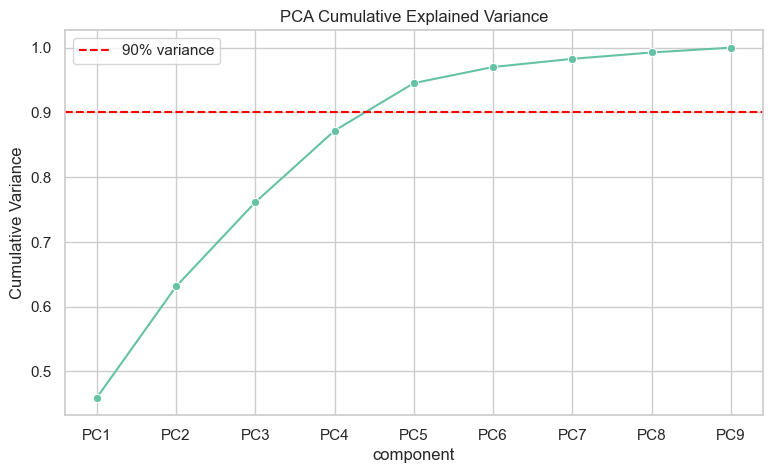

In [9]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(pca_full.explained_variance_ratio_))],
    'explained_variance_ratio': pca_full.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(pca_full.explained_variance_ratio_)
})
display(explained)

plt.figure(figsize=(9, 5))
sns.lineplot(data=explained, x='component', y='cumulative_variance', marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
plt.title('PCA Cumulative Explained Variance')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.show()


In [10]:
n_components = int(np.argmax(explained['cumulative_variance'] >= 0.90) + 1)
print('Components needed for at least 90% variance:', n_components)

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
pca_df.insert(0, 'country', countries)
display(pca_df.head())


Components needed for at least 90% variance: 5


,country,PC1,PC2,PC3,PC4,PC5
0,Afghanistan,-2.913025,0.095621,-0.718118,1.005255,-0.158310
1,Albania,0.429911,-0.588156,-0.333486,-1.161059,0.174677
2,Algeria,-0.285225,-0.455174,1.221505,-0.868115,0.156475
3,Angola,-2.932423,1.695555,1.525044,0.839625,-0.273209
4,Antigua and Barbuda,1.033576,0.136659,-0.225721,-0.847063,-0.193007


In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X.columns
)
display(loadings.style.background_gradient(cmap='coolwarm', axis=None).format('{:.2f}'))


,PC1,PC2,PC3,PC4,PC5
child_mort,-0.42,0.19,-0.03,0.37,-0.17
exports,0.28,0.61,0.14,0.00,0.06
health,0.15,-0.24,-0.60,0.46,0.52
imports,0.16,0.67,-0.30,-0.07,0.26
income,0.40,0.02,0.30,0.39,-0.25
inflation,-0.19,-0.01,0.64,0.15,0.71
life_expec,0.43,-0.22,0.11,-0.20,0.11
total_fer,-0.40,0.16,0.02,0.38,-0.14
gdpp,0.39,-0.05,0.12,0.53,-0.18


## 7. K-Means Clustering

  File "C:\Users\vrath\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,inertia,silhouette_score
0,2,1050.214558,0.287357
1,3,831.424435,0.283296
2,4,700.391720,0.302108
3,5,620.163371,0.299259
4,6,550.877188,0.230149
5,7,495.807946,0.247681
6,8,457.586148,0.238811


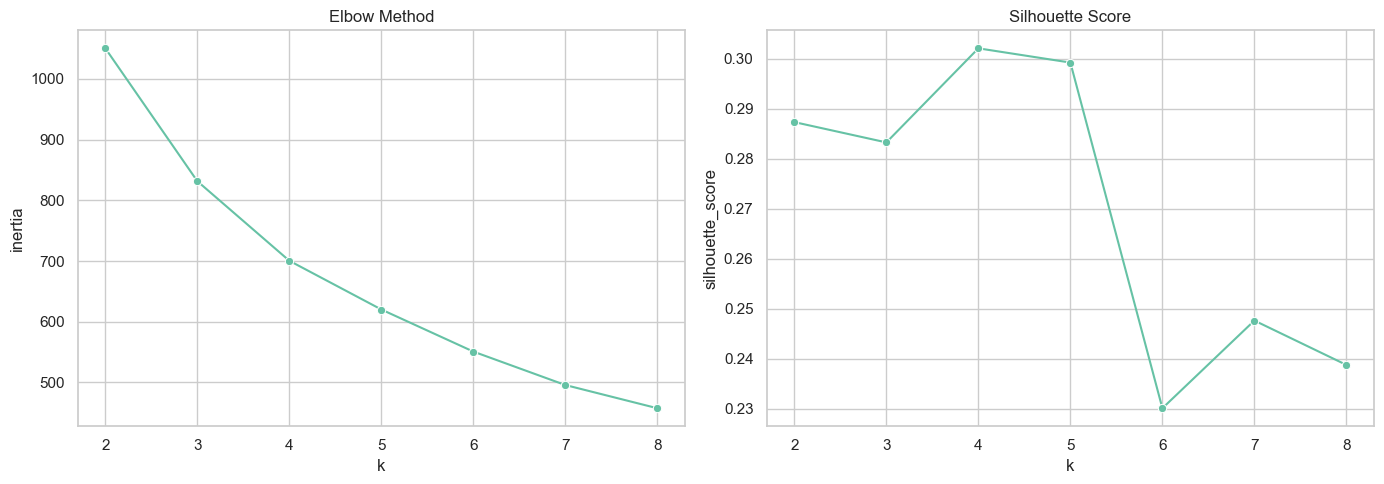

In [12]:
cluster_range = range(2, 9)
inertias = []
silhouettes = []

for k in cluster_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

cluster_metrics = pd.DataFrame({
    'k': list(cluster_range),
    'inertia': inertias,
    'silhouette_score': silhouettes
})
display(cluster_metrics)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=cluster_metrics, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('Elbow Method')
sns.lineplot(data=cluster_metrics, x='k', y='silhouette_score', marker='o', ax=axes[1])
axes[1].set_title('Silhouette Score')
plt.tight_layout()
plt.show()


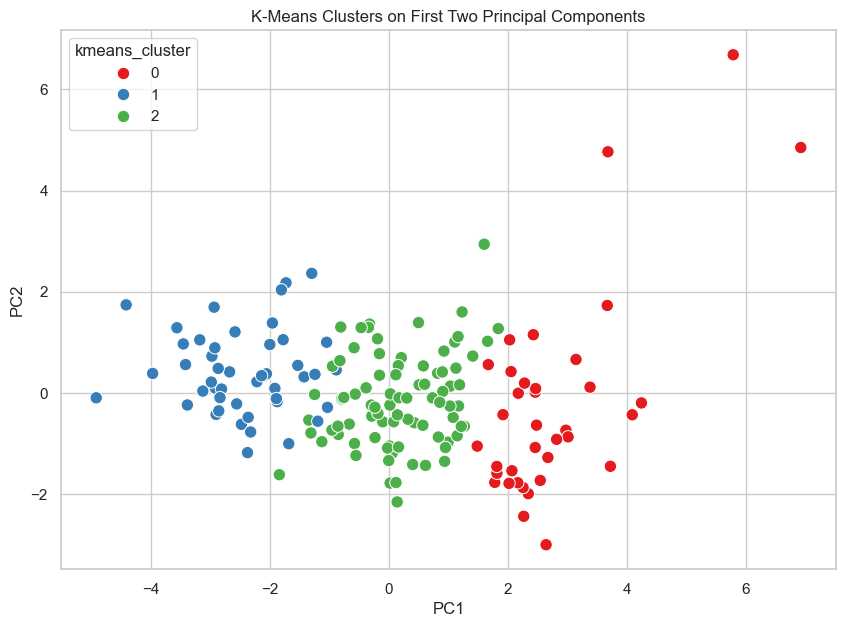

In [13]:
# Three clusters give interpretable groups: high development, developing, and aid priority.
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=20)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
pca_df['kmeans_cluster'] = df['kmeans_cluster']

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='kmeans_cluster',
    palette='Set1',
    s=80
)
plt.title('K-Means Clusters on First Two Principal Components')
plt.show()


## 8. DBSCAN Clustering

In [14]:
dbscan_results = []

for eps in [1.5, 2.0, 2.5, 3.0, 3.5]:
    for min_samples in [3, 4, 5]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
        noise_count = int(np.sum(labels == -1))
        score = np.nan
        if cluster_count >= 2:
            score = silhouette_score(X_scaled, labels)
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'clusters': cluster_count,
            'noise_points': noise_count,
            'silhouette_score': score
        })

dbscan_summary = pd.DataFrame(dbscan_results).sort_values(
    ['clusters', 'silhouette_score'],
    ascending=[False, False]
)
display(dbscan_summary)


,eps,min_samples,clusters,noise_points,silhouette_score
0,1.5,3,2,25,0.154047
1,1.5,4,1,29,NaN
2,1.5,5,1,30,NaN
3,2.0,3,1,11,NaN
4,2.0,4,1,12,NaN
5,2.0,5,1,15,NaN
6,2.5,3,1,6,NaN
7,2.5,4,1,6,NaN
8,2.5,5,1,6,NaN
9,3.0,3,1,6,NaN


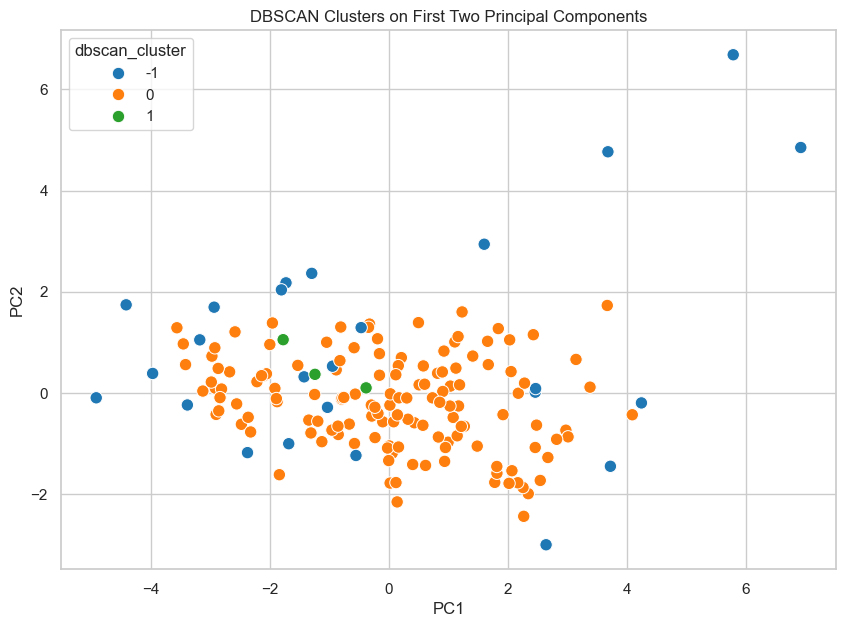

dbscan_cluster
-1     25
 0    139
 1      3
Name: country_count, dtype: int64

In [15]:
# DBSCAN is useful for identifying unusual countries, but K-Means gives cleaner policy groups here.
best_dbscan = dbscan_summary.dropna(subset=['silhouette_score']).iloc[0]
dbscan = DBSCAN(eps=best_dbscan['eps'], min_samples=int(best_dbscan['min_samples']))
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
pca_df['dbscan_cluster'] = df['dbscan_cluster']

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='dbscan_cluster',
    palette='tab10',
    s=80
)
plt.title('DBSCAN Clusters on First Two Principal Components')
plt.show()

display(df['dbscan_cluster'].value_counts().sort_index().rename('country_count'))


## 9. Hierarchical Clustering

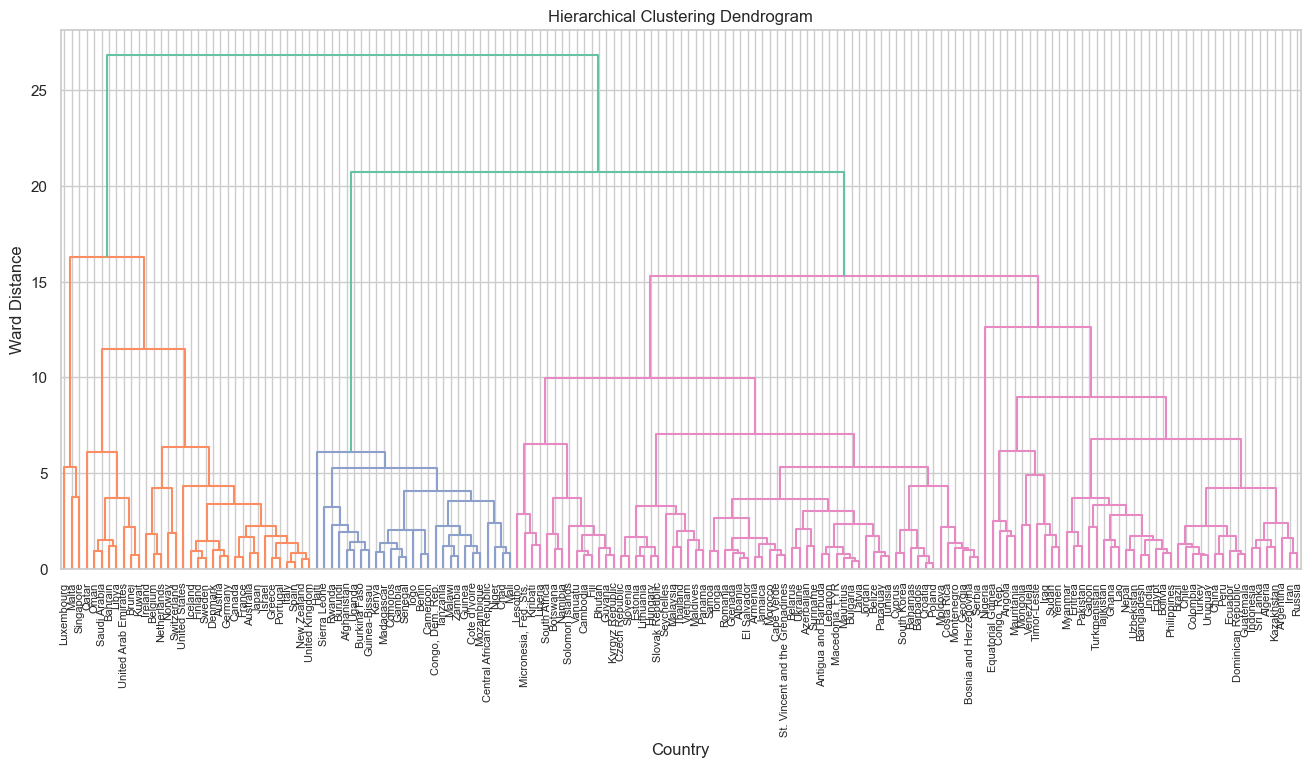

In [16]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(16, 7))
dendrogram(linked, labels=countries.values, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Country')
plt.ylabel('Ward Distance')
plt.show()


In [17]:
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['hierarchical_cluster'] = hierarchical.fit_predict(X_scaled)
pca_df['hierarchical_cluster'] = df['hierarchical_cluster']

pd.crosstab(df['kmeans_cluster'], df['hierarchical_cluster'], rownames=['K-Means'], colnames=['Hierarchical'])


Hierarchical,0,1,2
K-Means,,,
0,31,5,0
1,0,20,27
2,3,81,0


## 10. Cluster Profiling

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,country_count
kmeans_cluster,,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44,36
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38,47
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45,84


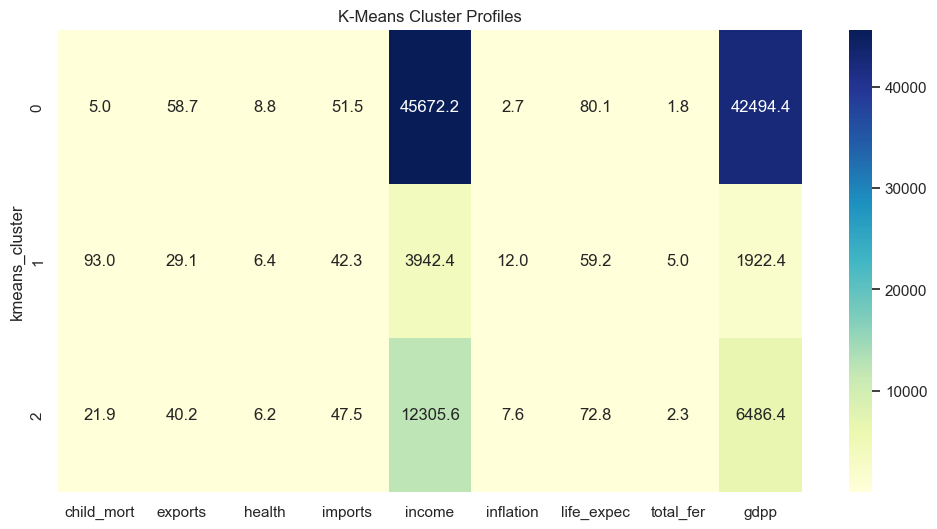

In [18]:
cluster_profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
cluster_profile['country_count'] = df['kmeans_cluster'].value_counts().sort_index()
display(cluster_profile)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile[numeric_cols], annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('K-Means Cluster Profiles')
plt.show()


In [19]:
# Label clusters by development need using cluster averages.
# Higher child mortality, higher fertility, lower income, lower GDP, and lower life expectancy indicate greater aid need.
need_score = (
    cluster_profile['child_mort'].rank(ascending=True) +
    cluster_profile['total_fer'].rank(ascending=True) +
    cluster_profile['income'].rank(ascending=False) +
    cluster_profile['gdpp'].rank(ascending=False) +
    cluster_profile['life_expec'].rank(ascending=False)
)

priority_cluster = int(need_score.idxmax())
developed_cluster = int(need_score.idxmin())
middle_cluster = int([c for c in cluster_profile.index if c not in [priority_cluster, developed_cluster]][0])

cluster_labels = {
    priority_cluster: 'Aid priority',
    middle_cluster: 'Developing / transition',
    developed_cluster: 'Relatively developed'
}

df['cluster_label'] = df['kmeans_cluster'].map(cluster_labels)
display(df[['country', 'kmeans_cluster', 'cluster_label']].head())
print('Priority cluster:', priority_cluster)


,country,kmeans_cluster,cluster_label
0,Afghanistan,1,Aid priority
1,Albania,2,Developing / transition
2,Algeria,2,Developing / transition
3,Angola,1,Aid priority
4,Antigua and Barbuda,2,Developing / transition


Priority cluster: 1


## 11. Final Country Prioritization

In [20]:
priority_df = df[df['cluster_label'] == 'Aid priority'].copy()

# Country-level score: large values mean stronger need for aid.
priority_df['aid_need_score'] = (
    priority_df['child_mort'].rank(ascending=True, pct=True) +
    priority_df['total_fer'].rank(ascending=True, pct=True) +
    priority_df['income'].rank(ascending=False, pct=True) +
    priority_df['gdpp'].rank(ascending=False, pct=True) +
    priority_df['life_expec'].rank(ascending=False, pct=True)
)

top_priority = priority_df.sort_values(
    ['aid_need_score', 'child_mort'],
    ascending=[False, False]
)[['country', 'child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'aid_need_score']]

display(top_priority.head(15))


,country,child_mort,income,gdpp,life_expec,total_fer,aid_need_score
37,"Congo, Dem. Rep.",116.0,609,334,57.5,6.54,4.393617
112,Niger,123.0,814,348,58.8,7.49,4.297872
31,Central African Republic,149.0,888,446,47.5,5.21,4.244681
26,Burundi,93.6,764,231,57.7,6.26,4.127660
132,Sierra Leone,160.0,1220,399,55.0,5.20,4.106383
106,Mozambique,101.0,918,419,54.5,5.56,4.042553
94,Malawi,90.5,1030,459,53.1,5.31,3.808511
32,Chad,150.0,1930,897,56.5,6.59,3.702128
25,Burkina Faso,116.0,1430,575,57.9,5.87,3.648936
64,Guinea-Bissau,114.0,1390,547,55.6,5.05,3.627660


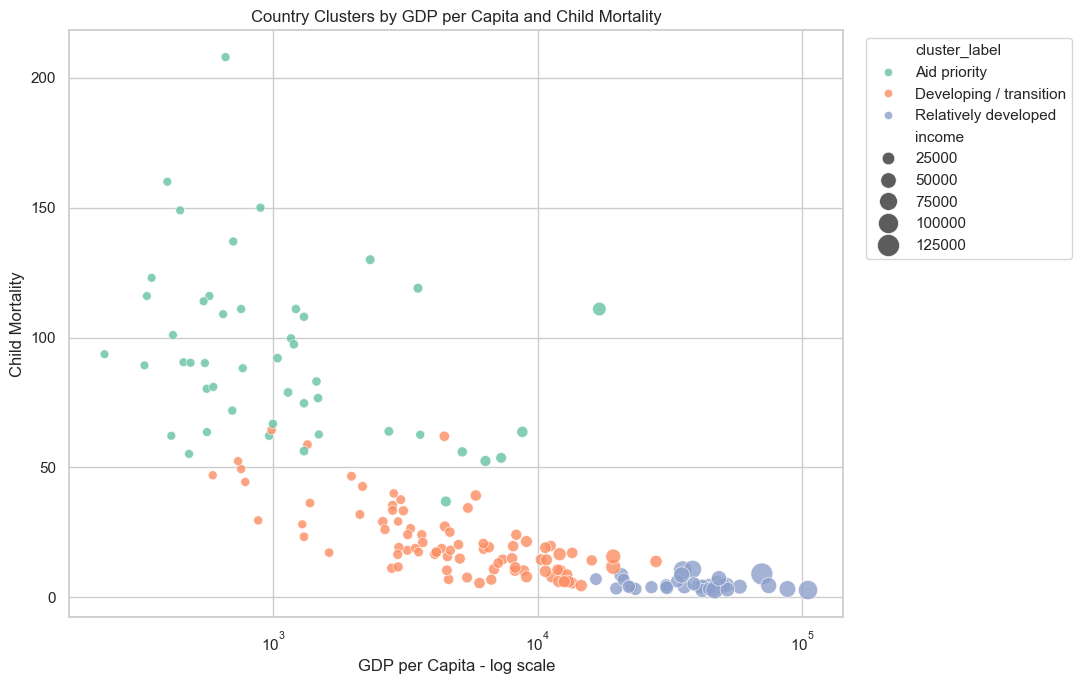

In [21]:
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df,
    x='gdpp',
    y='child_mort',
    hue='cluster_label',
    size='income',
    sizes=(40, 250),
    alpha=0.8
)
plt.xscale('log')
plt.title('Country Clusters by GDP per Capita and Child Mortality')
plt.xlabel('GDP per Capita - log scale')
plt.ylabel('Child Mortality')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 12. Conclusion

The clustering model separates countries into three meaningful groups:

- **Aid priority:** high child mortality and fertility, low income, low GDP per capita, and lower life expectancy.
- **Developing / transition:** moderate economic and health indicators.
- **Relatively developed:** high income and GDP per capita, high life expectancy, and low child mortality.

The recommended aid focus should be the countries in the **Aid priority** cluster, especially the top-ranked countries in the final prioritization table. These countries combine the most severe health risks with the weakest economic capacity.

K-Means is selected as the final model because it creates clear, interpretable country groups for strategic aid allocation. DBSCAN is kept as a supporting method for detecting unusual country profiles, while Hierarchical clustering validates the broad grouping pattern.
